# 0003_20260803_blur_test 結果確認

`experiment.py` が `data/trident_processed/20x_224px_0px_overlap/patches/{wsi_id}_patches.h5` に
追記した `blur_score` データセットを検証する。

- `results.json`(サマリ)と h5 側(生の値)が一致しているか
- 分布・空間マップの目視確認
- (任意)実パッチ画像でのぼやけ具合の目視確認

In [25]:
from pathlib import Path


def find_project_root(marker: str = "pyproject.toml") -> Path:
    """notebooks/ から見て、marker を持つ最初の親ディレクトリを返す。"""
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"{marker} が見つかりません（cwd={here}）")


PROJECT_ROOT = find_project_root()
EXP_NAME = "0003_20260803_blur_test"
WSI_ID = "64307"

RESULTS_JSON = PROJECT_ROOT / "outputs" / EXP_NAME / "default" / "results.json"
H5_PATH = (
    PROJECT_ROOT
    / "data"
    / "trident_processed"
    / "20x_224px_0px_overlap"
    / "patches"
    / f"{WSI_ID}_patches.h5"
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_JSON:", RESULTS_JSON, "exists:", RESULTS_JSON.exists())
print("H5_PATH:     ", H5_PATH, "exists:", H5_PATH.exists())

PROJECT_ROOT: /workspace/filesrv02/honzawa/01-toxpatho/toxpatho-ssl-comparison
RESULTS_JSON: /workspace/filesrv02/honzawa/01-toxpatho/toxpatho-ssl-comparison/outputs/0003_20260803_blur_test/default/results.json exists: True
H5_PATH:      /workspace/filesrv02/honzawa/01-toxpatho/toxpatho-ssl-comparison/data/trident_processed/20x_224px_0px_overlap/patches/64307_patches.h5 exists: True


## 1. results.json の中身

In [26]:
import json

results = json.loads(RESULTS_JSON.read_text())
results

[{'wsi_id': '10306',
  'n_patches': 18117,
  'blur_min': 0.5728036165237427,
  'blur_median': 1311.9576416015625,
  'blur_max': 2662.9169921875}]

## 2. h5 側の生データを確認

`coords`（TRIDENT座標、既存）と `blur_score`（今回 `append_blur_scores_from_wsi` が追記した値）の
2データセットが入っているはず。件数の一致・NaN の有無を確認する。

In [27]:
import h5py
import numpy as np

with h5py.File(H5_PATH, "r") as f:
    print("keys:", list(f.keys()))
    coords = f["coords"][:]
    blur_score = f["blur_score"][:]

print("coords shape:     ", coords.shape)
print("blur_score shape: ", blur_score.shape)

assert len(coords) == len(blur_score), "coords と blur_score の件数が一致しない"
assert not np.isnan(blur_score).any(), "blur_score に NaN が含まれる"

print(f"n_patches:   {len(blur_score)}")
print(f"blur_min:    {blur_score.min():.4f}")
print(f"blur_median: {np.median(blur_score):.4f}")
print(f"blur_mean:   {blur_score.mean():.4f}")
print(f"blur_max:    {blur_score.max():.4f}")

keys: ['blur_score', 'coords']
coords shape:      (16105, 2)
blur_score shape:  (16105,)
n_patches:   16105
blur_min:    1.2397
blur_median: 2017.2273
blur_mean:   1894.0249
blur_max:    3351.8535


## 3. results.json との整合性チェック

In [28]:
r = results[0]
assert r["n_patches"] == len(blur_score)
assert abs(r["blur_min"] - float(blur_score.min())) < 1e-3
assert abs(r["blur_max"] - float(blur_score.max())) < 1e-3
print("OK: results.json と h5 の値が一致")

AssertionError: 

## 4. 分布を可視化

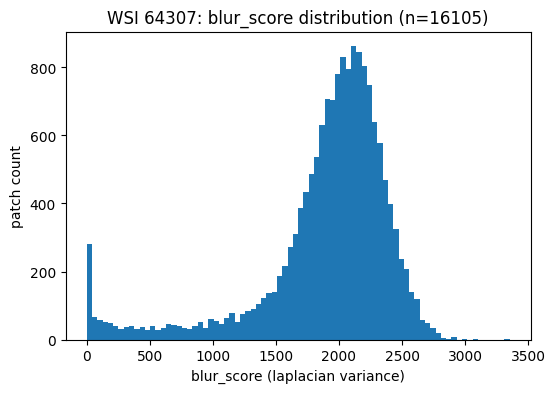

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(blur_score, bins=80)
ax.set_xlabel("blur_score (laplacian variance)")
ax.set_ylabel("patch count")
ax.set_title(f"WSI {WSI_ID}: blur_score distribution (n={len(blur_score)})")
plt.show()

## 5. 組織上の空間マップ

座標ごとに blur_score を色付けして表示する。特定領域だけ極端にぼやけている等の
異常があれば、ここで気付きやすい。

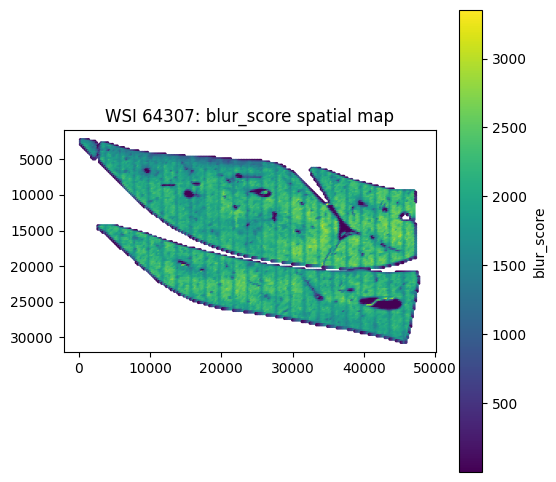

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=blur_score, s=2, cmap="viridis")
ax.invert_yaxis()  # 画像座標系（原点が左上）に合わせる
ax.set_aspect("equal")
ax.set_title(f"WSI {WSI_ID}: blur_score spatial map")
plt.colorbar(sc, ax=ax, label="blur_score")
plt.show()

## 6.（任意）実パッチ画像で目視確認

`openslide` が未インストール（`uv sync` 未実行）の場合はここだけスキップする。
blur_score が低い＝ぼやけているはずのパッチと、高い＝シャープなはずのパッチを
並べて、スコアの意味が実際の見た目と合っているか確認する。

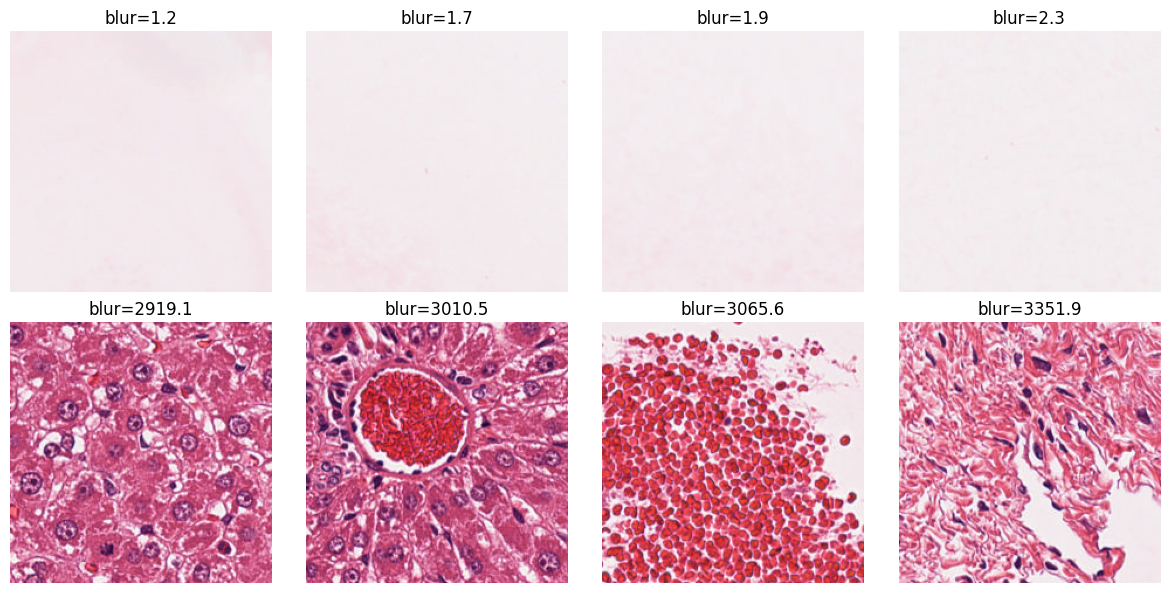

In [31]:
try:
    from openslide import OpenSlide
    HAS_OPENSLIDE = True
except ImportError:
    HAS_OPENSLIDE = False
    print(
        "openslide が未インストールのためスキップ。"
        " pyproject.toml に追加済みなので、`make uv_sync p=<partition>` 実行後に再実行してください。"
    )

if HAS_OPENSLIDE:
    WSI_PATH = PROJECT_ROOT / "data" / "raw_slide" / f"{WSI_ID}.svs"
    patch_size = 224
    n_show = 4

    order = np.argsort(blur_score)
    blurriest_idx = order[:n_show]
    sharpest_idx = order[-n_show:]

    wsi = OpenSlide(str(WSI_PATH))
    try:
        fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
        for col, idx in enumerate(blurriest_idx):
            x, y = coords[idx]
            patch = wsi.read_region((int(x), int(y)), 0, (patch_size, patch_size)).convert("RGB")
            axes[0, col].imshow(patch)
            axes[0, col].set_title(f"blur={blur_score[idx]:.1f}")
            axes[0, col].axis("off")
        for col, idx in enumerate(sharpest_idx):
            x, y = coords[idx]
            patch = wsi.read_region((int(x), int(y)), 0, (patch_size, patch_size)).convert("RGB")
            axes[1, col].imshow(patch)
            axes[1, col].set_title(f"blur={blur_score[idx]:.1f}")
            axes[1, col].axis("off")
        axes[0, 0].set_ylabel("blurriest")
        axes[1, 0].set_ylabel("sharpest")
        plt.tight_layout()
        plt.show()
    finally:
        wsi.close()